FLIGHT DELAY PREDICTION USING ANN

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import joblib

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [5]:
pd.read_csv("/content/Airlines.csv")

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3.0,15.0,205.0,1.0
1,2,US,1558,PHX,CLT,3.0,15.0,222.0,1.0
2,3,AA,2400,LAX,DFW,3.0,20.0,165.0,1.0
3,4,AA,2466,SFO,DFW,3.0,20.0,195.0,1.0
4,5,AS,108,ANC,SEA,3.0,30.0,202.0,0.0
...,...,...,...,...,...,...,...,...,...
31685,31686,XE,2318,IAH,ATL,4.0,1060.0,124.0,1.0
31686,31687,XE,2551,JAX,IAH,4.0,1060.0,149.0,0.0
31687,31688,XE,2807,PBI,IAH,4.0,1060.0,165.0,0.0
31688,31689,XE,2902,IAH,LFT,4.0,1060.0,53.0,0.0


In [7]:
df = pd.read_csv("/content/Airlines.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (94233, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3.0,15.0,205.0,1.0
1,2,US,1558,PHX,CLT,3.0,15.0,222.0,1.0
2,3,AA,2400,LAX,DFW,3.0,20.0,165.0,1.0
3,4,AA,2466,SFO,DFW,3.0,20.0,195.0,1.0
4,5,AS,108,ANC,SEA,3.0,30.0,202.0,0.0


In [8]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

DATASET INFORMATION

Rows: 94233
Columns: 9

Column Names:
['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

Data Types:
id               int64
Airline         object
Flight           int64
AirportFrom     object
AirportTo       object
DayOfWeek      float64
Time           float64
Length         float64
Delay          float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94233 entries, 0 to 94232
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           94233 non-null  int64  
 1   Airline      94233 non-null  object 
 2   Flight       94233 non-null  int64  
 3   AirportFrom  94233 non-null  object 
 4   AirportTo    94233 non-null  object 
 5   DayOfWeek    94232 non-null  float64
 6   Time         94232 non-null  float64
 7   Length       94232 non-null  float64
 8   Delay        94232 non-null  float64
dtypes: float64(4), int64(

In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,94233.0,NaN,NaN,NaN,47117.0,27202.868295,1.0,23559.0,47117.0,70675.0,94233.0
Airline,94233,18,WN,16501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight,94233.0,NaN,NaN,NaN,2435.45101,2071.043638,1.0,731.0,1805.0,3748.0,7813.0
AirportFrom,94233,290,ATL,6034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AirportTo,94233,291,ATL,6223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeek,94232.0,NaN,NaN,NaN,4.565519,1.778676,1.0,3.0,5.0,6.0,7.0
Time,94232.0,NaN,NaN,NaN,780.482936,274.201493,10.0,545.0,755.0,1006.0,1439.0
Length,94232.0,NaN,NaN,NaN,131.079941,69.489592,23.0,80.0,115.0,160.0,655.0
Delay,94232.0,NaN,NaN,NaN,0.353606,0.478091,0.0,0.0,0.0,1.0,1.0


In [10]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (missing.values / len(df)) * 100
})

display(missing_df)

,Column,Missing Values,Missing Percentage
0,id,0,0.000000
1,Airline,0,0.000000
2,Flight,0,0.000000
3,AirportFrom,0,0.000000
4,AirportTo,0,0.000000
5,DayOfWeek,1,0.001061
6,Time,1,0.001061
7,Length,1,0.001061
8,Delay,1,0.001061


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print("New dataset shape:", df.shape)

No duplicate rows found.
New dataset shape: (94233, 9)


In [14]:
print(df["Delay"].value_counts())

print("\nPercentage:")
print(df["Delay"].value_counts(normalize=True) * 100)

Delay
0.0    60911
1.0    33321
Name: count, dtype: int64

Percentage:
Delay
0.0    64.639401
1.0    35.360599
Name: proportion, dtype: float64


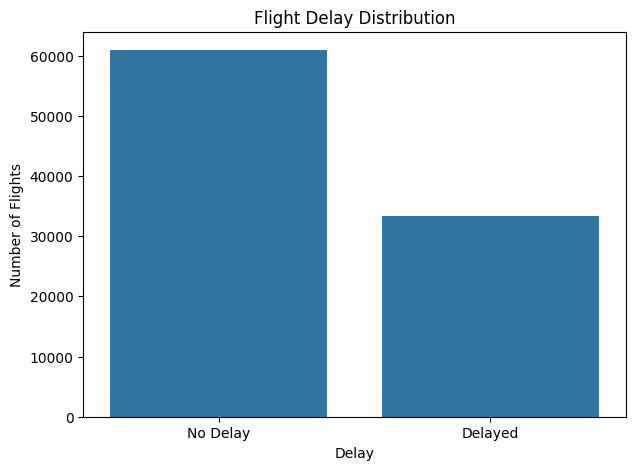

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Delay"
)

plt.title("Flight Delay Distribution")
plt.xlabel("Delay")
plt.ylabel("Number of Flights")
plt.xticks([0, 1], ["No Delay", "Delayed"])

plt.show()

In [16]:
categorical_columns = [
    "Airline",
    "AirportFrom",
    "AirportTo"
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print("=" * 50)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(20))


Airline
Unique values: 18
Airline
WN    16501
DL    10869
OO     8785
AA     8088
MQ     6555
US     6014
XE     5212
EV     4995
UA     4937
FL     3628
9E     3580
CO     3480
B6     2973
YV     2282
OH     2182
AS     2039
F9     1130
HA      983
Name: count, dtype: int64

AirportFrom
Unique values: 290
AirportFrom
ATL    6034
ORD    4373
DFW    3922
DEN    3431
LAX    2917
IAH    2635
PHX    2601
DTW    2276
LAS    2136
SFO    2077
CLT    1953
MCO    1808
MSP    1793
SLC    1790
BOS    1732
EWR    1635
JFK    1598
LGA    1546
BWI    1507
SEA    1402
Name: count, dtype: int64

AirportTo
Unique values: 291
AirportTo
ATL    6223
ORD    4441
DFW    3998
DEN    3482
LAX    2890
IAH    2698
PHX    2634
DTW    2333
LAS    2122
SFO    2067
CLT    1993
SLC    1832
MSP    1827
MCO    1821
BOS    1706
EWR    1639
JFK    1635
LGA    1545
BWI    1505
SEA    1382
Name: count, dtype: int64


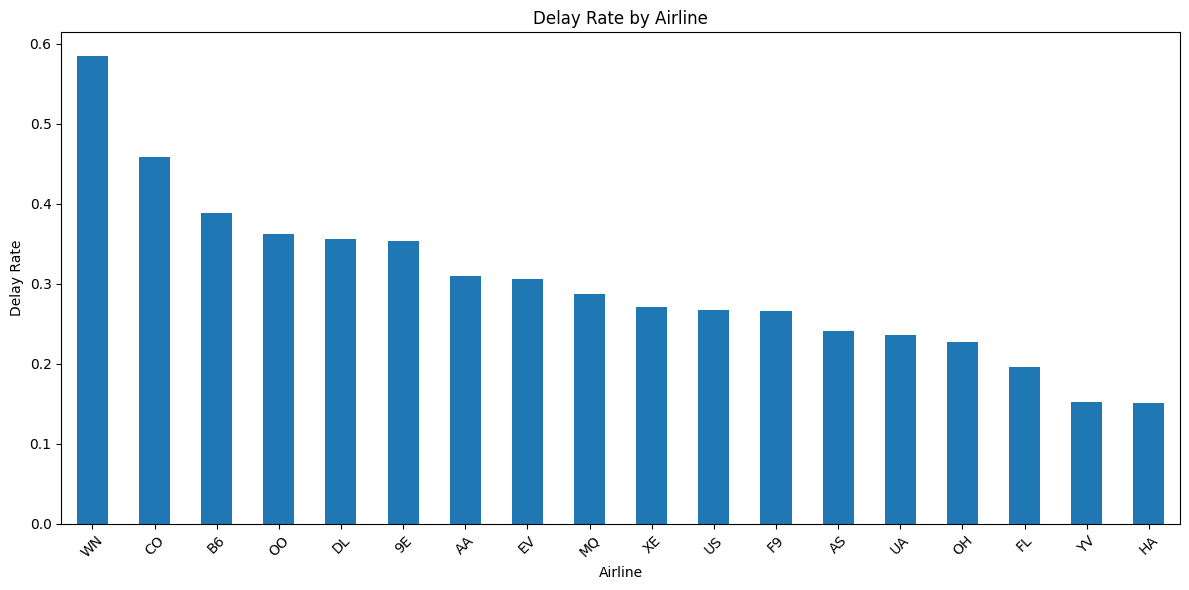

In [17]:
airline_delay = (
    df.groupby("Airline")["Delay"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

airline_delay.plot(kind="bar")

plt.title("Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

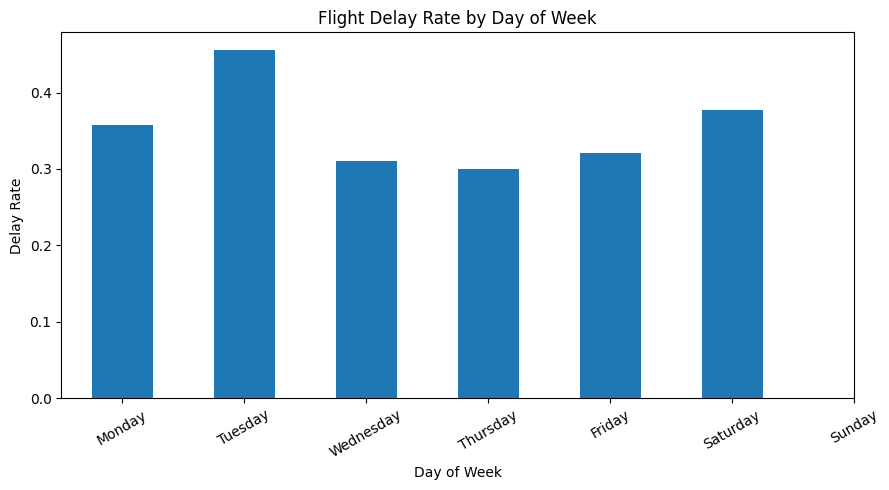

In [18]:
day_delay = (
    df.groupby("DayOfWeek")["Delay"]
    .mean()
)

plt.figure(figsize=(9, 5))

day_delay.plot(kind="bar")

plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday",
     "Thursday", "Friday", "Saturday", "Sunday"],
    rotation=30
)

plt.tight_layout()
plt.show()

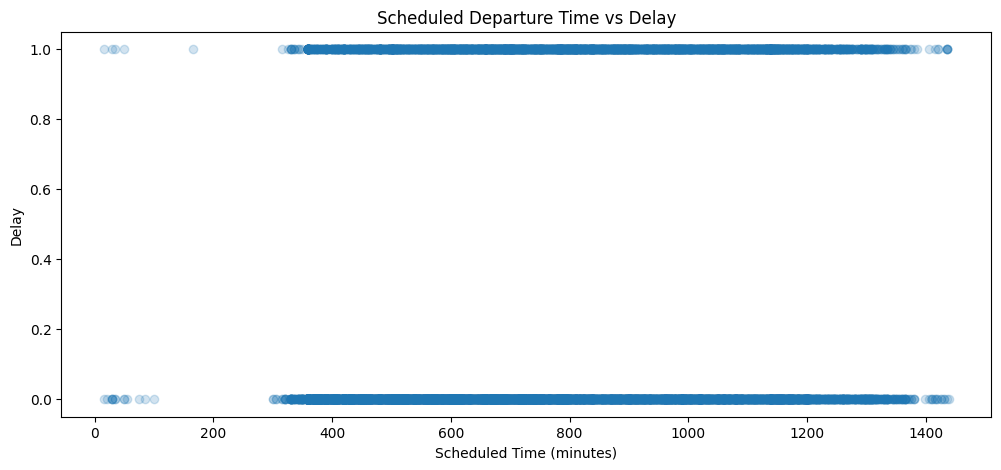

In [19]:
plt.figure(figsize=(12, 5))

plt.scatter(
    df["Time"].sample(10000, random_state=42),
    df.loc[df["Time"].sample(10000, random_state=42).index, "Delay"],
    alpha=0.2
)

plt.title("Scheduled Departure Time vs Delay")
plt.xlabel("Scheduled Time (minutes)")
plt.ylabel("Delay")

plt.show()

In [20]:
# Create a copy
data = df.copy()

# Remove ID
data = data.drop(columns=["id"])

print("Remaining columns:")
print(data.columns.tolist())

Remaining columns:
['Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']


In [21]:
X = data.drop(columns=["Delay"])
y = data["Delay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (94233, 7)
y shape: (94233,)


In [22]:
categorical_features = [
    "Airline",
    "AirportFrom",
    "AirportTo"
]

numerical_features = [
    "Flight",
    "DayOfWeek",
    "Time",
    "Length"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Airline', 'AirportFrom', 'AirportTo']

Numerical features:
['Flight', 'DayOfWeek', 'Time', 'Length']


In [24]:
data.dropna(subset=['Delay'], inplace=True)
X = data.drop(columns=["Delay"])
y = data["Delay"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (65962, 7)
Validation: (14135, 7)
Testing: (14135, 7)


In [25]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Delay
0.0    0.646387
1.0    0.353613
Name: proportion, dtype: float64

Validation distribution:
Delay
0.0    0.64641
1.0    0.35359
Name: proportion, dtype: float64

Testing distribution:
Delay
0.0    0.64641
1.0    0.35359
Name: proportion, dtype: float64


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (65962, 602)
Processed validation shape: (14135, 602)
Processed testing shape: (14135, 602)


In [28]:
X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print(X_train_processed.dtype)
print(X_val_processed.dtype)
print(X_test_processed.dtype)

float32
float32
float32


In [29]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")
print(class_weights)

Class weights:
{np.float32(0.0): np.float64(0.7735300326007928), np.float32(1.0): np.float64(1.4139764201500535)}


In [30]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        77,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,321 (345.00 KB)

 Trainable params: 87,937 (343.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [32]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [34]:
history = model.fit(
    X_train_processed,
    y_train,

    validation_data=(
        X_val_processed,
        y_val
    ),

    epochs=50,
    batch_size=1024,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6858 - auc: 0.7473 - loss: 0.5937 - precision: 0.5460 - recall: 0.6622 - val_accuracy: 0.6754 - val_auc: 0.7165 - val_loss: 0.6060 - val_precision: 0.5363 - val_recall: 0.6056 - learning_rate: 2.5000e-04
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6861 - auc: 0.7492 - loss: 0.5918 - precision: 0.5457 - recall: 0.6712 - val_accuracy: 0.6714 - val_auc: 0.7166 - val_loss: 0.6066 - val_precision: 0.5309 - val_recall: 0.6072 - learning_rate: 2.5000e-04
Epoch 3/50
63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6885 - auc: 0.7511 - loss: 0.5911 - precision: 0.5491 - recall: 0.6725
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6875 - auc: 0.7505 - loss: 0.5911 - precision: 0.5472 - recall: 0.6732 - val_accuracy: 0.6711 - val_auc: 0.7168 - val_loss: 0.6076 - val_precision: 0.5302 - val_recall: 0.6134 - learning_rate: 2.5

In [35]:
history_df = pd.DataFrame(history.history)

display(history_df.tail())

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
3,0.688609,0.752773,0.588452,0.548315,0.677513,0.672161,0.716733,0.607589,0.531553,0.613445,0.000125
4,0.688002,0.752959,0.589410,0.547434,0.679100,0.669756,0.716830,0.608279,0.528370,0.614846,0.000125
5,0.687835,0.752926,0.588241,0.547330,0.677728,0.670039,0.716776,0.608438,0.528645,0.616647,0.000125
6,0.689124,0.754081,0.587782,0.548652,0.681458,0.669968,0.716767,0.608473,0.528544,0.616847,0.000063
7,0.688851,0.753865,0.587819,0.548519,0.678800,0.669402,0.716949,0.608377,0.527887,0.615446,0.000063


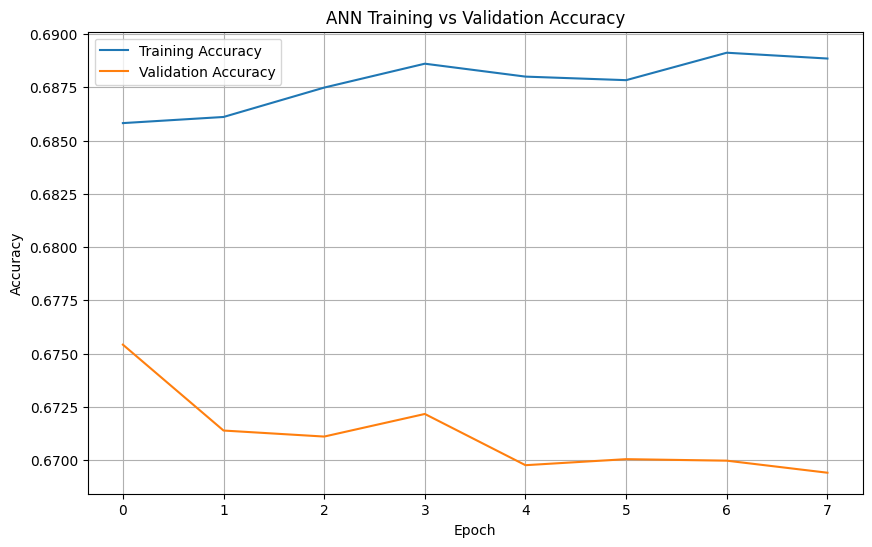

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

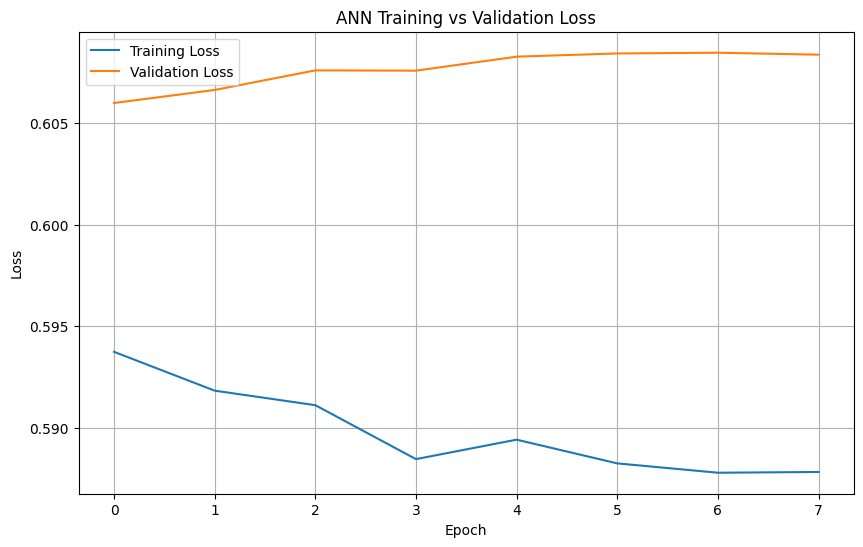

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
test_results = model.evaluate(
    X_test_processed,
    y_test,
    verbose=1
)

print("\nTest Results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6879 - auc: 0.7345 - loss: 0.5925 - precision: 0.5520 - recall: 0.6226

Test Results:
loss: 0.5925
compile_metrics: 0.6879


In [39]:
y_probability = model.predict(
    X_test_processed,
    batch_size=2048,
    verbose=1
).ravel()

# Default threshold
threshold = 0.50

y_pred = (
    y_probability >= threshold
).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

average_precision = average_precision_score(
    y_test,
    y_probability
)

print("=" * 60)
print("FINAL ANN PERFORMANCE")
print("=" * 60)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Accuracy (%)      : {accuracy * 100:.2f}%")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {average_precision:.4f}")

FINAL ANN PERFORMANCE
Accuracy          : 0.6879
Accuracy (%)      : 68.79%
Precision         : 0.5520
Recall            : 0.6226
F1 Score          : 0.5852
ROC-AUC           : 0.7346
Average Precision : 0.6153


In [41]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Delay",
            "Delayed"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

    No Delay     0.7780    0.7235    0.7498      9137
     Delayed     0.5520    0.6226    0.5852      4998

    accuracy                         0.6879     14135
   macro avg     0.6650    0.6731    0.6675     14135
weighted avg     0.6981    0.6879    0.6916     14135



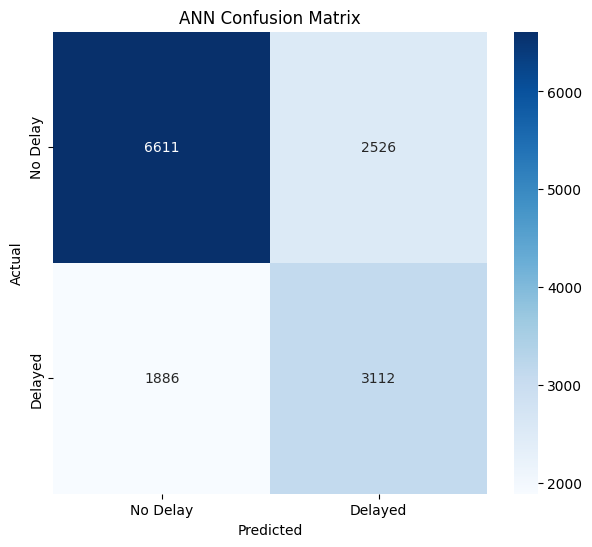

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Delay", "Delayed"],
    yticklabels=["No Delay", "Delayed"]
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
model.save(
    "flight_delay_ann_model.keras"
)

print("ANN model saved successfully.")

ANN model saved successfully.


In [44]:
joblib.dump(
    preprocessor,
    "flight_delay_preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [45]:
joblib.dump(
    preprocessor,
    "flight_delay_preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [50]:
from google.colab import files

files.download(
    "flight_delay_ann_model.keras"
)

files.download(
    "flight_delay_preprocessor.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
new_flight = pd.DataFrame({
    "Airline": ["AA"],
    "Flight": [2400],
    "AirportFrom": ["LAX"],
    "AirportTo": ["DFW"],
    "DayOfWeek": [3],
    "Time": [600],
    "Length": [165]
})

display(new_flight)

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length
0,AA,2400,LAX,DFW,3,600,165


In [52]:
new_flight_processed = preprocessor.transform(
    new_flight
).astype(np.float32)

print(
    "Processed shape:",
    new_flight_processed.shape
)

Processed shape: (1, 602)


In [54]:
delay_probability = model.predict(
    new_flight_processed
)[0][0]

print(
    f"Delay Probability: {delay_probability * 100:.2f}%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Delay Probability: 31.10%


In [56]:
prediction = (
    delay_probability >= threshold
)

if prediction:
    print("✈️ Prediction: FLIGHT DELAYED")
else:
    print("✈️ Prediction: FLIGHT NOT DELAYED")

✈️ Prediction: FLIGHT NOT DELAYED
